# MetaQ — VQ-VAE codebook metacells

> Li et al. *Discrete cellular states inferred via vector quantization on
> single-cell genomics data.* **Nature Communications** 16, 5236 (2025).
> [doi:10.1038/s41467-025-56424-6](https://doi.org/10.1038/s41467-025-56424-6)

**Algorithm.** A VQ-VAE-style encoder maps each cell to a 32-dimensional latent
vector, then a learned **discrete codebook** of size ``entry_num`` quantizes
each cell to its nearest codebook entry.  Each codebook entry is one metacell;
the cells assigned to it form the metacell.

**Capabilities.** ``soft``, ``latent``, ``codebook``, ``out_of_sample``,
``multimodal``, ``streaming``.

**Strengths.** **Linear-time, constant-memory** (unlike SEACells' O(N²)).
The encoder + codebook give you a **closed-form out-of-sample projection**
(`assign_new_cells`) — the only backend with this property.  Multi-omic
input via concatenated encoders.

**Weaknesses.** Needs GPU + PyTorch (CPU works but slow).  Requires raw
counts.  Hyperparameter tuning (`entry_dim`, `train_epoch`) matters more
than for graph methods.

## 1. Setup

In [1]:
# Standard imports + omicverse defaults.
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import omicverse as ov
import scvelo as scv      # only used for the demo dataset

ov.plot_set()

🔬 Starting plot initialization...
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.0   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 2. Load and preprocess

In [2]:
# Pancreas scRNA-seq (Bastidas-Ponce et al. 2019). Standard omicverse
# preprocess flow: qc -> preprocess -> scale -> pca -> neighbors -> umap.
adata = scv.datasets.pancreas()
adata = ov.pp.qc(adata,
                 tresh={'mito_perc': 0.20, 'nUMIs': 500, 'detected_genes': 250},
                 mt_startswith='mt-')
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson', n_HVGs=2000)
adata.layers['lognorm'] = adata.X.copy()        # mcRigor reads this
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata, layer='scaled', n_pcs=30)
adata.obsm['X_pca'] = adata.obsm['scaled|original|X_pca']
ov.pp.neighbors(adata, n_neighbors=15, use_rep='X_pca')
ov.pp.umap(adata)
print('adata:', adata.shape, 'celltypes:', sorted(adata.obs['clusters'].unique()))

🖥️ Using CPU mode for QC...

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 0 ⚠️               │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 0 ⚠️               │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘

   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range (Min - Max)       │
   ├─────────────────────

   ✓ Final filtering: 0 cells, 12,261 genes removed

🔍 Step 4: Doublet Detection
   💡 Running pyscdblfinder (Python port of R scDblFinder)
   🔍 Running scdblfinder detection...


[ScDblFinder] wrote scDblFinder_score + scDblFinder_class — threshold=0.387
   ✓ scDblFinder completed: 66 doublets removed (1.8%)

╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 16.9846s                                                │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (float)                              │
│           │ ✚ detected_genes (int)                                 │
│           │ ✚ hb_perc (float)                                      │
│           │ ✚ mito_perc (float)                                    │
│           │ ✚ nUMIs (float)                                        │
│           │ ✚ n_counts (float)                                     │
│           │ ✚ 

🔍 [2026-05-19 17:37:06] Running preprocessing in 'cpu' mode...
Begin robust gene identification


    After filtration, 15737/15737 genes are kept.
    Among 15737 genes, 15736 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson


...


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.7183s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 3630x2000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=30
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (3630, 2000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (1.60s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 1.6064s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 3630x30)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction

   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 3,630 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 8.7233s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯
🔍 [2026-05-19 17:37:19] Running UMAP in 'cpu' mode...
🖥️ Using Scanpy CPU UMAP...

🔍 UMAP Dimensionality Reduction:
   Mode: cpu
   Method: umap
   Components: 2
   Min distan


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 3,630 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 0.8341s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': 0.5830300199950147, 'b': 1.334166993228519}│
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
adata: (3630, 2000)

## 3. Fit MetaQ on GPU

MetaQ ignores `use_rep` — it has its own encoder reading from raw counts.
Training converges in <80 epochs on this dataset.  We use the dependency-free
``codebook_init='random'`` here ('kmeans' requires faiss).

In [3]:
mc = ov.single.MetaCell(
    adata.copy(), method='metaq', n_metacells=100,
    device='cuda', train_epoch=80, warm_epochs=10, batch_size=512,
    codebook_init='random', random_state=0,
).fit()
print(f'codebook shape: {mc.codebook().shape}')

[Epoch 1] RNA: Loss Rec=1.7653 


[Epoch 1] RNA: Loss Rec=0.9919 Loss Rec Q=1.0011 | Codebook: Loss C=0.0033


[Epoch 20] RNA: Loss Rec=0.9290 Loss Rec Q=0.9383 | Codebook: Loss C=0.0076


[Epoch 40] RNA: Loss Rec=0.9147 Loss Rec Q=0.9292 | Codebook: Loss C=0.0095


[Epoch 60] RNA: Loss Rec=0.9028 Loss Rec Q=0.9254 | Codebook: Loss C=0.0095


[Epoch 80] RNA: Loss Rec=0.8912 Loss Rec Q=0.9230 | Codebook: Loss C=0.0099
codebook shape: (100, 32)


## 4. AnnData schema after fit

Every backend writes the same fields into ``adata`` — that's what lets the
downstream helpers below work without branching on the backend.

In [4]:
# Inspect what the fit wrote into adata via the unified schema.
print(f'method      : {mc.method}')
print(f'capabilities: {sorted(mc.capabilities)}')
print(f'n_metacells : {np.unique(mc._fit_result.assignments).size}')
print(f'runtime     : {mc._fit_result.runtime_s:.3f} s')
print(f'uns         : {dict(mc.adata.uns["metacell"])}')

method      : metaq
capabilities: ['codebook', 'latent', 'multimodal', 'out_of_sample', 'soft', 'streaming']
n_metacells : 100
runtime     : 9.011 s
uns         : {'method': 'metaq', 'n_metacells': 100, 'n_iter': 80, 'converged': False, 'runtime_s': 9.011366844177246, 'random_state': 0, 'capabilities': ['codebook', 'latent', 'multimodal', 'out_of_sample', 'soft', 'streaming']}


## 5. Aggregate to a metacell AnnData

`predicted(method='hard', layer='counts', summary='sum')` returns a
metacell × gene AnnData with raw count totals preserved — the format that
downstream tools (SCENIC, CellPhoneDB, pseudobulk DE) actually want.

In [5]:
ad_mc = mc.predicted(method='hard', layer='counts', summary='sum',
                     celltype_label='clusters')
print(f'metacell AnnData: {ad_mc.shape}')
print(f'mean cells/metacell: {ad_mc.obs["n_cells"].mean():.1f}')
ad_mc.obs.head()

metacell AnnData: (100, 2000)
mean cells/metacell: 36.3


,n_cells,clusters,clusters_purity
mc-0,46,Alpha,0.978261
mc-1,49,Ductal,0.877551
mc-2,38,Pre-endocrine,0.526316
mc-3,38,Ngn3 high EP,1.000000
mc-4,51,Ductal,1.000000


## 6. Benchmarking metrics (purity / separation / compactness)

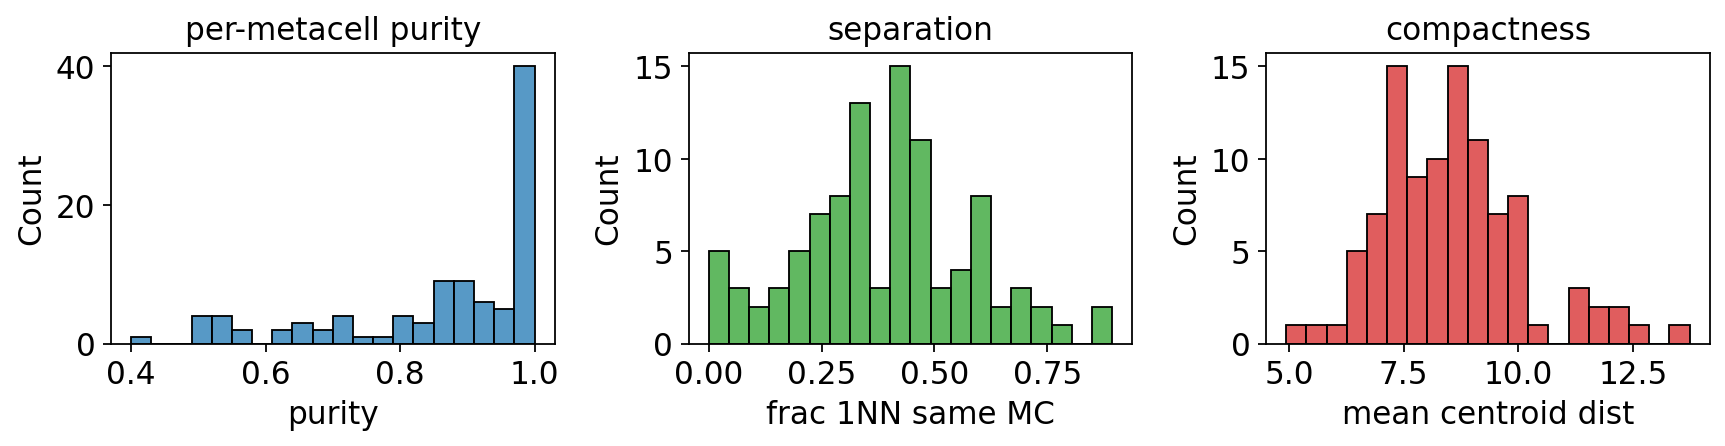

In [6]:
# Compute purity / separation / compactness AND show the 3-panel histogram
# in one call (ov.pl.metacell_metrics returns the per-metacell tables too).
purity, separation, compactness = ov.pl.metacell_metrics(
    mc, label_key='clusters', use_rep='X_pca',
)

## 7. mcRigor: statistical validation

For each metacell, mcRigor permutes the (cells × genes) submatrix in two
ways and asks: *is the observed gene–gene covariance bigger than the null
distribution at this metacell's size?*  Metacells whose `mcDiv` exceeds the
size-stratified threshold are flagged as `'dubious'`.

In [7]:
# mcRigor's double-permutation null. dubious_rate = fraction of cells in
# heterogeneous metacells; rigor_score = 1 - 0.5*(dubious_rate + zero_rate).
rep = mc.check_rigor(layer_lognorm='lognorm', n_rep=20,
                     feature_use=1000, random_state=0)
print(f'rigor_score : {rep.score:.3f}')
print(f'dubious_rate: {rep.dubious_rate:.3f}')
print(f'zero_rate   : {rep.zero_rate:.3f}')
print(f'# metacells : {rep.n_metacells}')

rigor_score : 0.625
dubious_rate: 0.507
zero_rate   : 0.244
# metacells : 100


### 7.1 Per-metacell `mcDiv` vs size

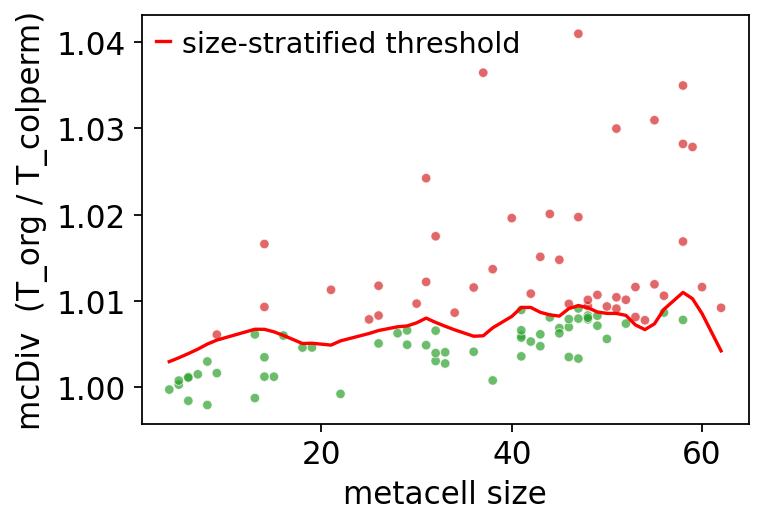

<Axes: xlabel='metacell size', ylabel='mcDiv  (T_org / T_colperm)'>

In [8]:
# mcDiv vs metacell size, overlaid with size-stratified threshold.
ov.pl.rigor_scatter(rep)

## 8. UMAP with metacell centroids

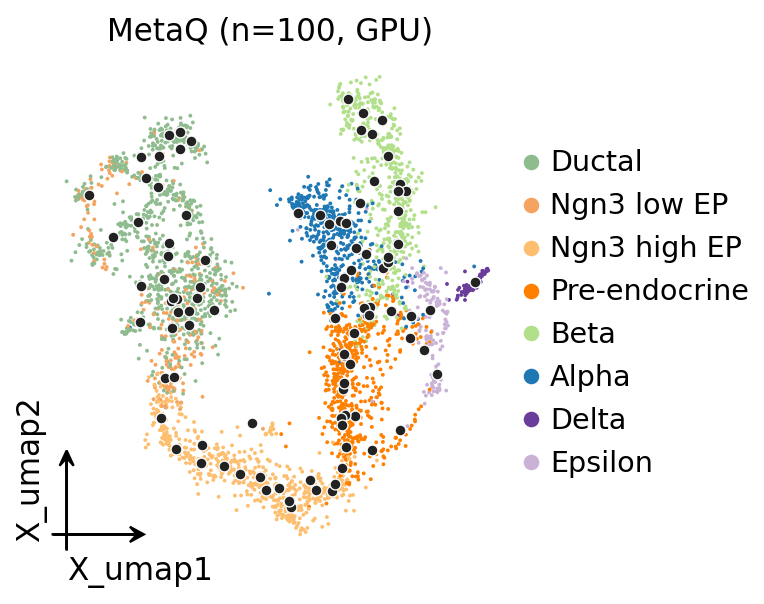

In [9]:
# UMAP coloured by celltype with metacell centroids overlaid in dark grey.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 4))
ov.pl.embedding(mc.adata, basis='X_umap', color='clusters', ax=ax, show=False,
                frameon='small', title='MetaQ (n=100, GPU)', size=12)
labels = mc._fit_result.assignments
pts = np.array([mc.adata.obsm['X_umap'][labels == u].mean(axis=0)
                for u in np.unique(labels)])
ax.scatter(pts[:, 0], pts[:, 1], s=24, c='#222',
           edgecolors='white', linewidths=0.6, zorder=5)
plt.tight_layout(); plt.show()

## 9. Per-celltype purity boxplot

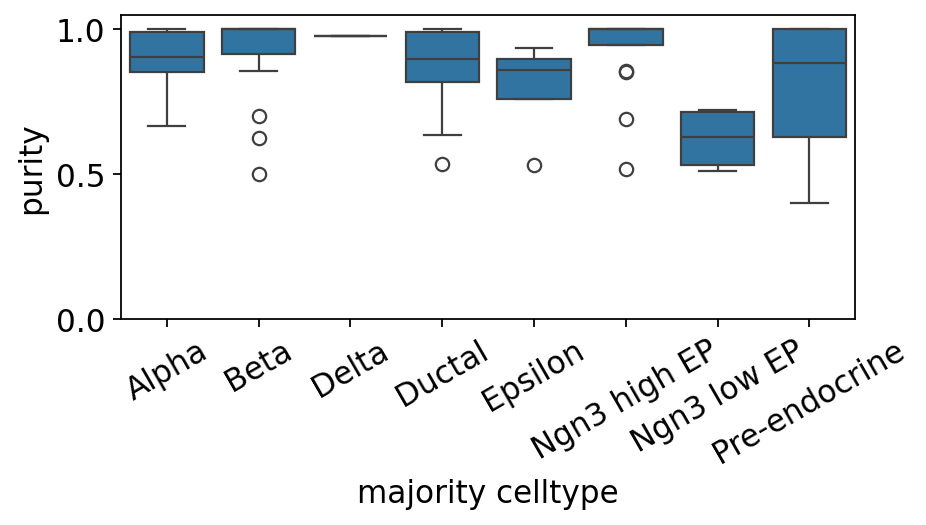

<Axes: xlabel='majority celltype', ylabel='purity'>

In [10]:
# Per-celltype boxplot of metacell purity.
ov.pl.metacell_purity_box(mc, label_key='clusters')

## 10. Metacell-level UMAP

A common downstream use of metacells is to treat them as a much smaller
"atlas" of pseudo-cells and re-run the standard omicverse preprocess → PCA
→ UMAP loop on them.  Cell-type signal should survive.

🔍 [2026-05-19 17:37:50] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 2000/2000 genes are kept.
    Among 2000 genes, 2000 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 0 highly-expressed genes from normalization computation
   Excluded genes: []

✅ Count Normalization Completed Successfully!
   ✓ Processed: 100 cells × 2,000 genes
   ✓ Runtime: 0.00s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100

✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 2,000 total (100.0%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': F

   🔧 PCA solver used: covariance_eigh
    finished✅ (0.99s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 0.996s                                                  │
│  Shape:    100 x 2,000 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 100x30)                                │
│           │ ✚ scaled|original|X_pca (array, 100x30)                │
│         

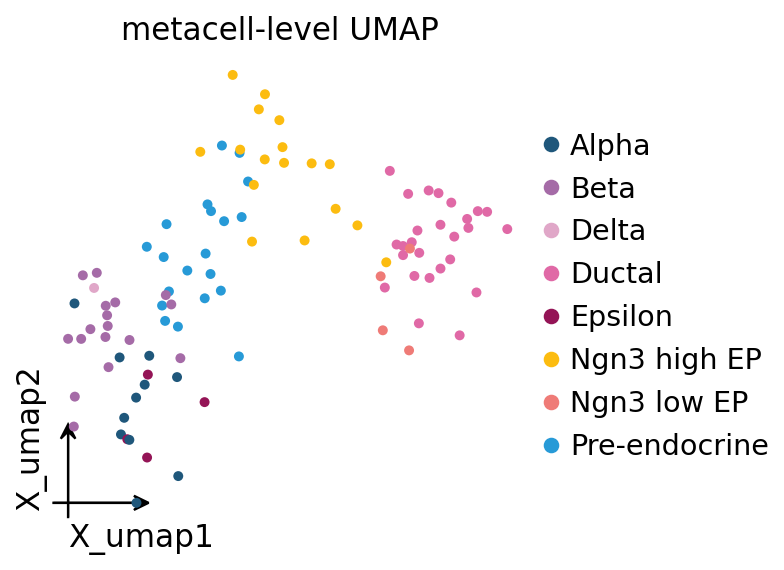

In [11]:
# Treat the metacell AnnData as a smaller dataset and run the standard
# omicverse preprocess -> pca -> neighbors -> umap loop on it.
ad_mc = ov.pp.preprocess(ad_mc, mode='shiftlog|pearson',
                          n_HVGs=min(2000, ad_mc.n_vars))
ad_mc = ad_mc[:, ad_mc.var.highly_variable_features]
ov.pp.scale(ad_mc)
ov.pp.pca(ad_mc, layer='scaled', n_pcs=min(30, ad_mc.n_obs - 1))
ad_mc.obsm['X_pca'] = ad_mc.obsm['scaled|original|X_pca']
ov.pp.neighbors(ad_mc, n_neighbors=min(15, ad_mc.n_obs - 1), use_rep='X_pca')
ov.pp.umap(ad_mc)
ov.pl.embedding(ad_mc, basis='X_umap', color='clusters',
                frameon='small', title='metacell-level UMAP', size=80)

## 11. Top markers per celltype on the metacell AnnData

In [12]:
# Find top markers per celltype on the metacell AnnData (omicverse helper —
# drops the categories with <2 metacells automatically and reports cell-type
# fractions ``pts`` along with the gene names).
counts = ad_mc.obs['clusters'].value_counts()
keep = counts[counts >= 2].index.tolist()
ad_mc_for_de = ad_mc[ad_mc.obs['clusters'].isin(keep)].copy()
ad_mc_for_de.obs['clusters'] = ad_mc_for_de.obs['clusters'].astype('category')

ov.single.find_markers(ad_mc_for_de, groupby='clusters', method='wilcoxon',
                       key_added='rank_genes_groups', pts=True, use_gpu=False)
ov.single.get_markers(ad_mc_for_de, n_genes=3, key='rank_genes_groups')

🔍 Finding marker genes | method: wilcoxon | groupby: clusters | n_groups: 7 | n_genes: 50
✅ Done | 7 groups × 50 genes | corr: benjamini-hochberg | stored in adata.uns['rank_genes_groups']


,group,rank,names,scores,logfoldchanges,pvals,pvals_adj,pct_group,pct_rest
0,Alpha,1,Tmem27,5.355475,6.228428,8.533180e-08,2.838448e-05,1.0,0.863636
1,Alpha,2,Smarca1,5.288671,3.350148,1.232082e-07,2.838448e-05,1.0,0.977273
2,Alpha,3,Ocrl,5.288671,3.271058,1.232082e-07,2.838448e-05,1.0,0.897727
3,Beta,1,Mapt,6.448282,6.121652,1.131249e-10,4.261192e-08,1.0,0.439024
4,Beta,2,Ero1lb,6.448282,4.778243,1.131249e-10,4.261192e-08,1.0,0.719512
5,Beta,3,Sec61b,6.429726,1.682800,1.278341e-10,4.261192e-08,1.0,1.000000
6,Ductal,1,Nudt19,7.537909,3.346427,4.775691e-14,5.743815e-12,1.0,1.000000
7,Ductal,2,Cyr61,7.529957,7.392430,5.075702e-14,5.743815e-12,1.0,0.616438
8,Ductal,3,Bex4,7.522006,1.513449,5.394225e-14,5.743815e-12,1.0,1.000000
9,Epsilon,1,Guca2b,3.376389,5.319087,7.344411e-04,8.312324e-02,1.0,0.357895


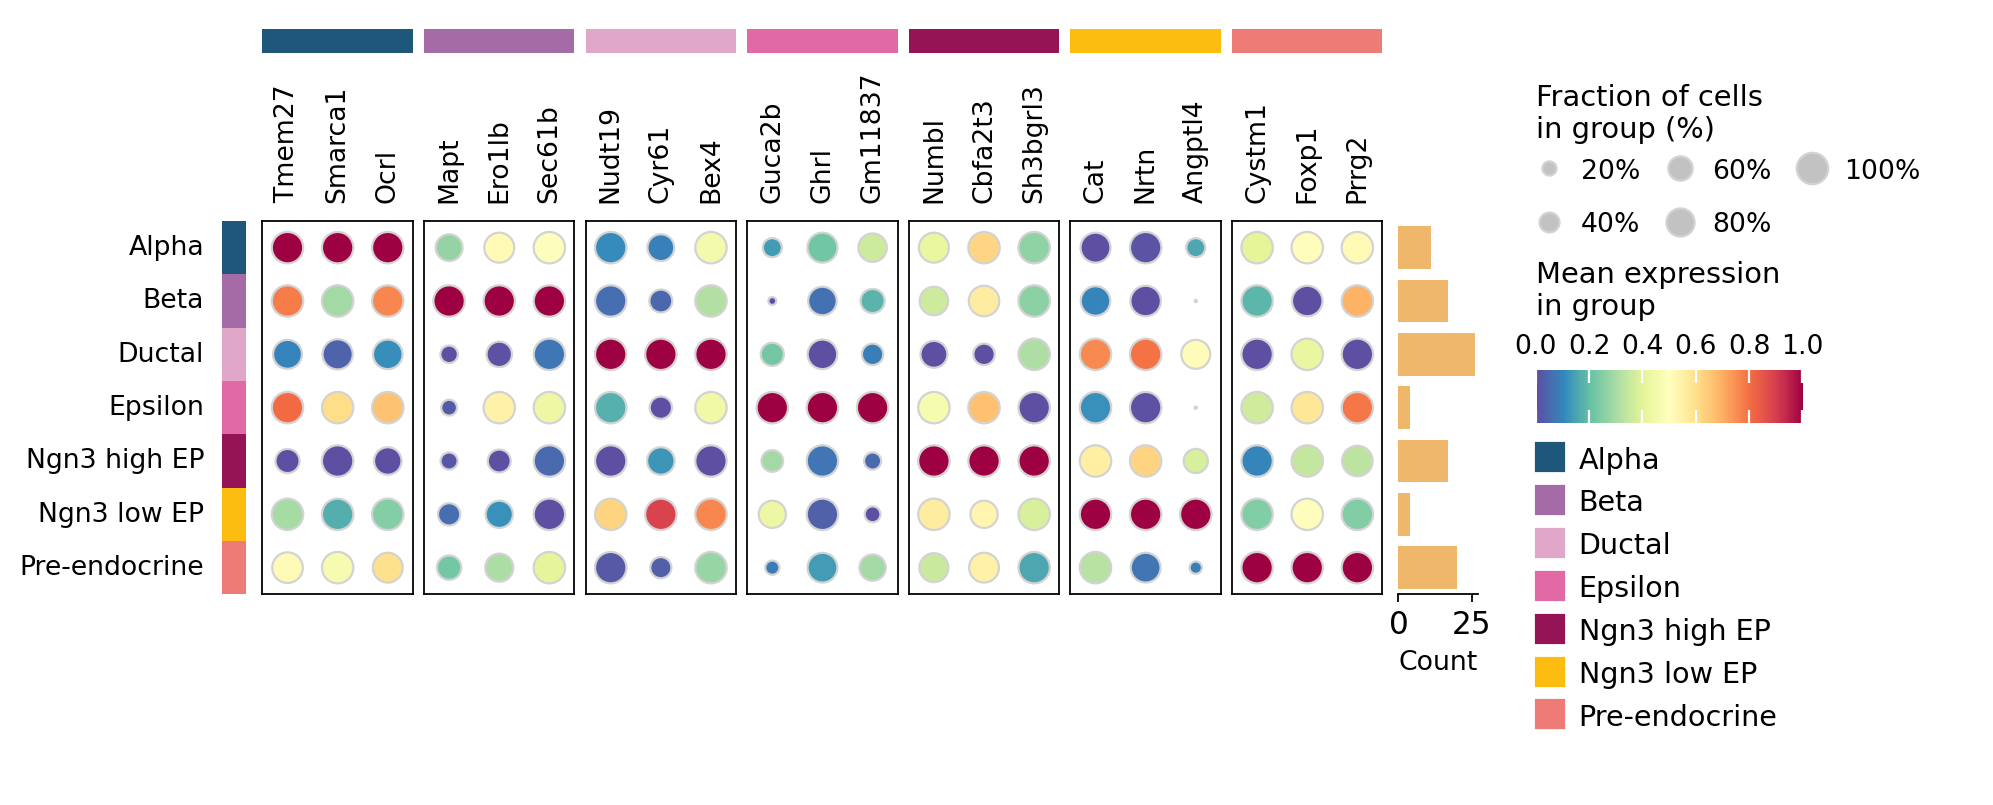

In [13]:
# Dotplot of top markers per metacell-level celltype.
ov.pl.markers_dotplot(ad_mc_for_de, groupby='clusters', n_genes=3,
                      key='rank_genes_groups')

## 12. MetaQ exclusive: out-of-sample + codebook UMAP

Because encoder and codebook are both parametric, **new cells can be assigned
to existing metacells without re-fitting** — the only backend with this
property.  The codebook itself can be UMAP'd to give a metacell-prototype
atlas (each dot = one metacell).

In [14]:
# Simulate "new cells" arriving after the metacell map was built — pick
# 500 held-out cells and snap them onto the existing codebook.
new_cells = adata[:500].copy()
assign = mc.assign_new_cells(new_cells)
for k, v in assign.items():
    print(f'  {k:12s}: shape={v.shape}, dtype={v.dtype}')
print(f'\n# distinct metacells touched: {len(np.unique(assign["metacell_id"]))}/{mc.n_metacells}')
print(f'mean confidence (cosine sim margin): {assign["confidence"].mean():.3f}')

  metacell_id : shape=(500,), dtype=int64
  confidence  : shape=(500,), dtype=float32
  embedding   : shape=(500, 32), dtype=float32

# distinct metacells touched: 96/100
mean confidence (cosine sim margin): 0.015


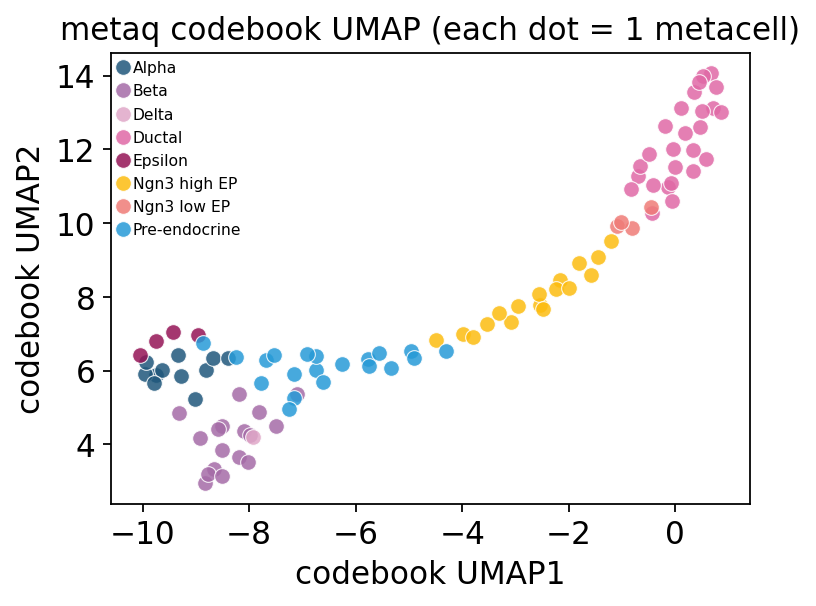

<Axes: title={'center': 'metaq codebook UMAP (each dot = 1 metacell)'}, xlabel='codebook UMAP1', ylabel='codebook UMAP2'>

In [15]:
# UMAP of the learned codebook — each dot is one metacell prototype,
# coloured by majority cell-level celltype.
ov.pl.metacell_codebook_umap(mc, label_key='clusters')

## 13. Save / load roundtrip

In [16]:
# Save/load roundtrip — every backend supports this.
import tempfile, os
with tempfile.NamedTemporaryFile(suffix='.pt', delete=False) as f:
    path = f.name
mc.save(path)

mc2 = ov.single.MetaCell(adata.copy(), method='metaq', n_metacells=100,
                          use_rep='X_pca', random_state=0)
mc2.load(path)
print(f'saved+loaded {path}')
os.remove(path)

saved+loaded /tmp/tmpylofitga.pt


## 14. Takeaways

- MetaQ is the **only** backend with closed-form out-of-sample projection.
- Scales linearly: a million-cell atlas fits comfortably in 8 GB GPU memory.
- The VQ-VAE objective is *not* the same as SEACells' archetypal analysis —
  it minimises reconstruction loss + commitment loss, not within-archetype
  variance.  In practice purity tends to be comparable.
- Codebook init matters: `'random'` (used here) is the safest dependency-free
  option; `'geometric'` (via vendored geosketch) gives even manifold coverage;
  `'kmeans'` warm-starts from k-means centroids but requires `faiss`.